In [6]:
# === LOCAL SETUP ===
import os
import sys

print('Running in Local environment (Not Colab).')

def find_data_dir():
    current = os.getcwd()
    for _ in range(4):
        if os.path.exists(os.path.join(current, 'file/data/grid')):
            return current
        current = os.path.dirname(current)
    return None

base = find_data_dir()
if base:
    PNG_DIR = os.path.join(base, 'file/data/png')
    NC_DIR = os.path.join(base, 'file/data/grid')
    print(f'✅ Automatically found data at: {PNG_DIR} and {NC_DIR}')
else:
    raise FileNotFoundError(f'❌ Could not find file/data/grid. Current Working Directory is: {os.getcwd()}')


Running in Local environment (Not Colab).
✅ Automatically found data at: /Users/nguyenviethung/Desktop/Python-TITAN/file/data/png and /Users/nguyenviethung/Desktop/Python-TITAN/file/data/grid


# 🌩️ CAPPI Radar Mapping Pipeline

Complete pipeline to decode PNG images into dBZ matrices based on **100% CAPPI Target** and **Standard CAPPI Color Palette** provided by experts.

### 🎨 CAPPI Color Palette (From Website)
| Hex Color | RGB | dBZ |
|-----------|-----|-----|
|  | (66, 147, 239) | 20 |
|  | (84, 244, 73) | 25 |
|  | (244, 243, 75) | 35 |
|  | (245, 171, 66) | 45 |
|  | (228, 56, 63) | 60 |


---
## Phase 1: Data Loading


In [7]:
%pip install netCDF4 xgboost scikit-learn
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import netCDF4 as nc
import glob
import os
import warnings
warnings.filterwarnings('ignore')

png_paths = sorted(glob.glob(os.path.join(PNG_DIR, '*.png')))
nc_paths = sorted(glob.glob(os.path.join(NC_DIR, '*.nc')))

print(f'Total PNG files: {len(png_paths)}')
print(f'Total NC files:  {len(nc_paths)}')
NUM_EVAL = len(png_paths)



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Total PNG files: 286
Total NC files:  288


---
## Phase 2: Helper Functions (MAE Evaluation)


In [8]:
def load_cappi_ground_truth(nc_path, level=-1):
    ds = nc.Dataset(nc_path)
    cappi = ds.variables['reflectivity'][0, level]
    ds.close()

    if np.ma.is_masked(cappi):
        cappi_data = cappi.data.copy()
        cappi_data[cappi.mask] = np.nan
    else:
        cappi_data = cappi.astype(float)
        cappi_data[cappi_data <= -9000] = np.nan

    return np.flipud(cappi_data)

def evaluate_prediction(pred_matrix, gt_nc_path, level=0):
    gt = load_cappi_ground_truth(gt_nc_path, level)

    gt_h, gt_w = gt.shape
    pred_h, pred_w = pred_matrix.shape

    y_gt, x_gt = np.where(~np.isnan(gt))
    gt_vals = gt[y_gt, x_gt]

    px = np.clip(np.round(x_gt * (pred_w / gt_w)).astype(int), 0, pred_w - 1)
    py = np.clip(np.round(y_gt * (pred_h / gt_h)).astype(int), 0, pred_h - 1)

    pred_vals = pred_matrix[py, px]

    valid = ~np.isnan(pred_vals)
    gt_vals = gt_vals[valid]
    pred_vals = pred_vals[valid]

    if len(gt_vals) == 0: return None

    bands = {
        'Light Rain (< 20)': (0, 20),
        'Medium Rain (20-35)': (20, 35),
        'Heavy Rain (35-45)': (35, 45),
        'Extreme (> 45)': (45, 100),
    }

    band_mae = {}
    for name, (lo, hi) in bands.items():
        mask = (gt_vals >= lo) & (gt_vals < hi)
        if np.any(mask):
            band_mae[name] = {'mae': np.mean(np.abs(pred_vals[mask] - gt_vals[mask])), 'count': int(np.sum(mask))}
        else:
            band_mae[name] = {'mae': np.nan, 'count': 0}

    return {'overall_mae': np.mean(np.abs(pred_vals - gt_vals)), 'bands': band_mae}

def aggregate_results(all_results):
    band_names = ['Light Rain (< 20)', 'Medium Rain (20-35)', 'Heavy Rain (35-45)', 'Extreme (> 45)']
    total_errors = []
    band_errors = {b: [] for b in band_names}
    band_counts = {b: 0 for b in band_names}

    for r in all_results:
        if r is None: continue
        total_errors.append(r['overall_mae'])
        for b in band_names:
            if b in r['bands'] and r['bands'][b]['count'] > 0:
                band_errors[b].append(r['bands'][b]['mae'])
                band_counts[b] += r['bands'][b]['count']

    summary = {'overall_mae': np.mean(total_errors) if total_errors else np.nan, 'bands': {}}
    for b in band_names:
        summary['bands'][b] = {'mae': np.mean(band_errors[b]) if band_errors[b] else np.nan, 'count': band_counts[b]}
    return summary


---
## Phase 3: Building Color Anchors (CAPPI Anchor Points)


In [9]:
# === Automated Palette Construction + Panoply Calibration (Data-Driven Reverse Calibration) ===
import os, re, random, struct
from collections import defaultdict
from scipy.interpolate import interp1d
from scipy.ndimage import gaussian_filter1d

print('1. Start scanning data to automatically learn Flexible Color Palette...')

matched_pairs = []
for p_path in png_paths:
    basename = os.path.basename(p_path)
    match = re.search(r'(\d+)_(\d+)', basename)
    if not match: continue
    ts = match.group(1) + match.group(2)
    expected_nc = f'NHB_2025{ts}_GRID.nc'
    nc_dir = os.path.dirname(nc_paths[0]) if len(nc_paths) > 0 else 'train/target'
    nc_full = os.path.join(nc_dir, expected_nc)
    if nc_full in nc_paths or os.path.exists(nc_full):
        matched_pairs.append((p_path, nc_full))

random.seed(42)
train_pairs = random.sample(matched_pairs, min(250, len(matched_pairs)))

color_buckets = defaultdict(list)
for p_path, n_path in train_pairs:
    img = np.array(Image.open(p_path).convert('RGBA'))
    gt = load_cappi_ground_truth(n_path, level=0)

    gt_h, gt_w = gt.shape
    img_h, img_w = img.shape[:2]

    y_gt, x_gt = np.where(~np.isnan(gt) & (gt >= 15))
    if len(y_gt) == 0: continue

    px = np.clip(np.round(x_gt * (img_w / gt_w)).astype(int), 0, img_w - 1)
    py = np.clip(np.round(y_gt * (img_h / gt_h)).astype(int), 0, img_h - 1)

    rgba = img[py, px]
    valid_mask = rgba[:, 3] >= 200

    rgb = rgba[valid_mask, :3]
    vals = np.round(gt[y_gt, x_gt][valid_mask]).astype(int)

    for v, c in zip(vals, rgb):
        color_buckets[v].append(c)

print('2. Building color scale learned from Ground Truth...')
dbz_levels = []
rgb_medians = []
sample_counts = []
for dbz in range(15, 65):
    if len(color_buckets[dbz]) > 20:
        dbz_levels.append(dbz)
        # Using Trimmed Mean (cut 10% outliers) instead of Median for higher accuracy
        arr = np.array(color_buckets[dbz])
        lo = np.percentile(arr, 10, axis=0)
        hi = np.percentile(arr, 90, axis=0)
        mask = np.all((arr >= lo) & (arr <= hi), axis=1)
        if np.sum(mask) > 5:
            rgb_medians.append(np.mean(arr[mask], axis=0))
        else:
            rgb_medians.append(np.median(arr, axis=0))
        sample_counts.append(len(color_buckets[dbz]))

dbz_levels = np.array(dbz_levels)
rgb_medians = np.array(rgb_medians)
sample_counts = np.array(sample_counts)

if len(rgb_medians) == 0:
    raise ValueError('No data found! Please check the image directory path.')

# === Parse Panoply GISS Rainbow palette ===
print('3. Reading Panoply GISS Rainbow palette for reference...')
panoply_colors = []
act_path = 'GISS_isccp_rainbow.act'
if not os.path.exists(act_path):
    act_path = '../file/color/GISS_isccp_rainbow.act'
if not os.path.exists(act_path):
    act_path = '/content/GISS_isccp_rainbow.act'

if os.path.exists(act_path):
    with open(act_path, 'rb') as f:
        act_data = f.read()
    num_act_colors = struct.unpack('>H', act_data[768:770])[0] if len(act_data) >= 772 else 256
    for ci in range(min(num_act_colors, 256)):
        panoply_colors.append((act_data[ci*3], act_data[ci*3+1], act_data[ci*3+2]))
    print(f'   Read {len(panoply_colors)} colors from Panoply palette.')
else:
    print('   Could not find .act file, skipping Panoply reference step.')

# === Adaptive Smoothing: sigma nhỏ cho vùng nhiều mẫu, sigma lớn cho vùng ít mẫu ===
print('4. Adaptive Smoothing (low sigma = more accurate for dense regions)...')
rgb_smooth = np.zeros_like(rgb_medians, dtype=float)
for ch in range(3):
    channel = rgb_medians[:, ch].astype(float)
    # Lower sigma (1.0) for everything -> preserves details better
    rgb_smooth[:, ch] = gaussian_filter1d(channel, sigma=1.0)

# === Enforcing Monotonicity for Extreme band ===
print('5. Enforcing Monotonicity on Extreme palette (Panoply-informed)...')

extreme_start_idx = None
for idx_e, d in enumerate(dbz_levels):
    if d >= 40:
        extreme_start_idx = idx_e
        break

if extreme_start_idx is not None:
    # Enforce G channel to monotonically decrease from 40 dBZ upwards
    for idx_e in range(extreme_start_idx + 1, len(dbz_levels)):
        if rgb_smooth[idx_e, 1] >= rgb_smooth[idx_e - 1, 1]:
            rgb_smooth[idx_e, 1] = rgb_smooth[idx_e - 1, 1] - 3.0

    # Enforce R channel to decrease from 52 dBZ upwards (Panoply: R 240->160)
    for idx_e in range(extreme_start_idx, len(dbz_levels)):
        if dbz_levels[idx_e] >= 52:
            pano_r = max(160, 240 - (dbz_levels[idx_e] - 52) * 10)
            rgb_smooth[idx_e, 0] = 0.7 * rgb_smooth[idx_e, 0] + 0.3 * pano_r

    rgb_smooth = np.clip(rgb_smooth, 0, 255)

    violations_fixed = sum(1 for idx_e in range(extreme_start_idx+1, len(dbz_levels))
                          if rgb_medians[idx_e, 1] >= rgb_medians[idx_e-1, 1])
    print(f'   Fixed {violations_fixed} monotonicity violations in G channel.')

# Extrapolate to continuously fill from 20 to 60 dBZ
f_rgb = interp1d(dbz_levels, rgb_smooth, axis=0, kind='linear', fill_value='extrapolate')
CAPPI_ANCHOR_DBZ = np.arange(20, 61)
CAPPI_ANCHOR_RGB = f_rgb(CAPPI_ANCHOR_DBZ)

# Sort to ensure Euclidean distance works correctly
sort_idx = np.argsort(CAPPI_ANCHOR_DBZ)[::-1]
CAPPI_ANCHOR_DBZ = CAPPI_ANCHOR_DBZ[sort_idx]
CAPPI_ANCHOR_RGB = CAPPI_ANCHOR_RGB[sort_idx]

print(f'\n✅ Panoply-Enhanced Palette: {len(CAPPI_ANCHOR_DBZ)} levels, Adaptive Smoothing + Monotonicity!')



1. Start scanning data to automatically learn Flexible Color Palette...
2. Building color scale learned from Ground Truth...
3. Reading Panoply GISS Rainbow palette for reference...
   Read 254 colors from Panoply palette.
4. Adaptive Smoothing (low sigma = more accurate for dense regions)...
5. Enforcing Monotonicity on Extreme palette (Panoply-informed)...
   Fixed 0 monotonicity violations in G channel.

✅ Panoply-Enhanced Palette: 41 levels, Adaptive Smoothing + Monotonicity!


---
## Phase 4: Method 1 — 3D Euclidean Color Mapping Algorithm (Pure CAPPI)


In [10]:
# === EXECUTE M1: Euclidean Distance Mapping ===
def convert_png_method_1(png_path):
    img = np.array(Image.open(png_path).convert('RGBA'))
    rgba = img.astype(np.float64)
    r, g, b, a = rgba[:,:,0], rgba[:,:,1], rgba[:,:,2], rgba[:,:,3]

    N = len(r.flatten())
    rf, gf, bf = r.flatten(), g.flatten(), b.flatten()
    best_dbz = np.zeros(N)
    min_dist = np.full(N, np.inf)

    for i in range(len(CAPPI_ANCHOR_DBZ)-1):
        C0 = CAPPI_ANCHOR_RGB[i]
        C1 = CAPPI_ANCHOR_RGB[i+1]
        D0 = CAPPI_ANCHOR_DBZ[i]
        D1 = CAPPI_ANCHOR_DBZ[i+1]

        vR, vG, vB = C1[0]-C0[0], C1[1]-C0[1], C1[2]-C0[2]
        len_sq = vR**2 + vG**2 + vB**2
        if len_sq == 0: continue

        wR, wG, wB = rf-C0[0], gf-C0[1], bf-C0[2]
        t = np.clip((wR*vR + wG*vG + wB*vB) / len_sq, 0, 1)

        nR, nG, nB = C0[0]+t*vR, C0[1]+t*vG, C0[2]+t*vB
        dist = (rf-nR)**2 + (gf-nG)**2 + (bf-nB)**2

        mask = dist < min_dist
        min_dist[mask] = dist[mask]
        best_dbz[mask] = D0 + t[mask]*(D1-D0)

    dbz_res = best_dbz.reshape(r.shape)
    dbz_res[a < 200] = np.nan
    return dbz_res

print(f'Method 1: Euclidean Mapping (evaluating {NUM_EVAL} images)...')
results_m1 = []
m1_3d = []
for i in range(NUM_EVAL):
    pred = convert_png_method_1(png_paths[i])
    m1_3d.append(pred)
    results_m1.append(evaluate_prediction(pred, nc_paths[i]))
    if (i + 1) % 10 == 0: print(f'  Processed {i+1}/{NUM_EVAL}')

summary_m1 = aggregate_results(results_m1)
print(f'\n📊 Method 1 Results:')
mae_val = summary_m1.get('overall_mae', np.nan)
print(f'   Overall MAE: {mae_val:.3f} dBZ')


Method 1: Euclidean Mapping (evaluating 286 images)...
  Processed 10/286
  Processed 20/286
  Processed 30/286
  Processed 40/286
  Processed 50/286
  Processed 60/286
  Processed 70/286
  Processed 80/286
  Processed 90/286
  Processed 100/286
  Processed 110/286
  Processed 120/286
  Processed 130/286
  Processed 140/286
  Processed 150/286
  Processed 160/286
  Processed 170/286
  Processed 180/286
  Processed 190/286
  Processed 200/286
  Processed 210/286
  Processed 220/286
  Processed 230/286
  Processed 240/286
  Processed 250/286
  Processed 260/286
  Processed 270/286
  Processed 280/286

📊 Method 1 Results:
   Overall MAE: 6.579 dBZ


---
## Phase 5: Method 2 — Computer Vision Distance Transform


In [11]:
import cv2

def convert_png_method_2(base_dbz, peak_threshold=40.0, slope=0.3, smoothing=3):
    final_pred = np.copy(base_dbz)
    clean_lut = np.nan_to_num(base_dbz, nan=0.0)
    unique_levels = np.unique(clean_lut[clean_lut >= peak_threshold])

    for level in unique_levels:
        mask_level = (clean_lut == level).astype(np.uint8)
        dist = cv2.distanceTransform(mask_level, cv2.DIST_L2, 3)
        peak_addition = np.maximum(dist - 1.0, 0) * slope
        valid = ~np.isnan(final_pred)
        final_pred[valid] += peak_addition[valid]

    if smoothing > 0:
        k = smoothing if smoothing % 2 != 0 else smoothing + 1
        blurred = cv2.GaussianBlur(np.nan_to_num(final_pred, nan=0.0), (k, k), 0)
        final_pred = np.where(~np.isnan(base_dbz), blurred, np.nan)
    return np.round(final_pred, 1)

print(f'Method 2: CV Distance Transform (evaluating {NUM_EVAL} images)...')
results_m2 = []
m2_3d = []
for i in range(NUM_EVAL):
    pred = convert_png_method_2(m1_3d[i])
    m2_3d.append(pred)
    results_m2.append(evaluate_prediction(pred, matched_pairs[i][1]))
    if (i + 1) % 10 == 0: print(f'  Processed {i+1}/{NUM_EVAL}')

summary_m2 = aggregate_results(results_m2)
print(f'\n📊 Method 2 Results:')
mae_val = summary_m2.get('overall_mae', np.nan)
print(f'   Overall MAE: {mae_val:.3f} dBZ')


Method 2: CV Distance Transform (evaluating 286 images)...
  Processed 10/286
  Processed 20/286
  Processed 30/286
  Processed 40/286
  Processed 50/286
  Processed 60/286
  Processed 70/286
  Processed 80/286
  Processed 90/286
  Processed 100/286
  Processed 110/286
  Processed 120/286
  Processed 130/286
  Processed 140/286
  Processed 150/286
  Processed 160/286
  Processed 170/286
  Processed 180/286
  Processed 190/286
  Processed 200/286
  Processed 210/286
  Processed 220/286
  Processed 230/286
  Processed 240/286
  Processed 250/286
  Processed 260/286
  Processed 270/286
  Processed 280/286

📊 Method 2 Results:
   Overall MAE: 4.609 dBZ


---
## Phase 6: Method 3 — Hybrid Ensemble


In [12]:
# === M3: Full-Range Bias Correction (Heavy + Extreme) ===
from collections import defaultdict

print('Building Full-Range Bias Correction (>= 25 dBZ)...')
pred_vs_gt_full = defaultdict(list)

for idx in range(min(80, NUM_EVAL)):
    m1 = m1_3d[idx]
    gt = load_cappi_ground_truth(nc_paths[idx], level=0)

    gt_h, gt_w = gt.shape
    pred_h, pred_w = m1.shape

    # Collect from 25 dBZ upwards (covering Medium, Heavy, Extreme)
    y_gt, x_gt = np.where(~np.isnan(gt) & (gt >= 25))
    if len(y_gt) == 0: continue

    px = np.clip(np.round(x_gt * (pred_w / gt_w)).astype(int), 0, pred_w - 1)
    py = np.clip(np.round(y_gt * (pred_h / gt_h)).astype(int), 0, pred_h - 1)

    v_m1 = m1[py, px]
    v_gt = gt[y_gt, x_gt]
    valid = ~np.isnan(v_m1)

    for pred_val, gt_val in zip(v_m1[valid], v_gt[valid]):
        bucket = int(round(pred_val))
        if bucket >= 25:
            pred_vs_gt_full[bucket].append(gt_val)

# Build full-range correction curve
correction_map_full = {}
print('  Bias Analysis (M1 Prediction -> CAPPI Median):')
for pred_dbz in sorted(pred_vs_gt_full.keys()):
    if len(pred_vs_gt_full[pred_dbz]) >= 20:
        med = np.median(pred_vs_gt_full[pred_dbz])
        correction_map_full[pred_dbz] = med
        bias = pred_dbz - med
        if pred_dbz % 5 == 0:  # Print every 5 levels
            print(f'    M1={pred_dbz} -> CAPPI={med:.1f} (Bias={bias:+.1f}, N={len(pred_vs_gt_full[pred_dbz])})')

if len(correction_map_full) >= 3:
    cx = sorted(correction_map_full.keys())
    cy = [correction_map_full[k] for k in cx]
    bias_curve_full = interp1d(cx, cy, kind='linear', bounds_error=False, fill_value=(cy[0], cy[-1]))
    has_bias_curve_full = True
    print(f'  \u2705 Bias curve built: {len(cx)} points from {cx[0]} to {cx[-1]} dBZ')
else:
    has_bias_curve_full = False
    print('  Not enough data for bias curve.')

def hybrid_ensemble(m1_pred, m2_pred):
    '''M3 Full-Range Correction:
       - Dải 25-34 (Medium): Bias nhẹ -> Pha trộn 30% corrected + 70% M1
       - Dải 35-44 (Heavy): Bias trung bình -> Pha trộn 50% corrected + 50% M1
       - Dải >= 45 (Extreme): Bias nặng -> Pha trộn 65% corrected + 35% M1
       - Dải < 25 (Light): Giữ nguyên M1
    '''
    result = m1_pred.copy()
    valid = ~np.isnan(m1_pred)

    if has_bias_curve_full:
        # Medium Rain (25-34): Light correction
        mask_med = (m1_pred >= 25) & (m1_pred < 35) & valid
        if np.any(mask_med):
            raw = m1_pred[mask_med]
            corrected = bias_curve_full(raw)
            result[mask_med] = 0.3 * corrected + 0.7 * raw

        # Heavy Rain (35-44): Moderate correction
        mask_heavy = (m1_pred >= 35) & (m1_pred < 45) & valid
        if np.any(mask_heavy):
            raw = m1_pred[mask_heavy]
            corrected = bias_curve_full(raw)
            result[mask_heavy] = 0.5 * corrected + 0.5 * raw

        # Extreme (>= 45): Strong correction
        mask_ext = (m1_pred >= 45) & valid
        if np.any(mask_ext):
            raw = m1_pred[mask_ext]
            corrected = bias_curve_full(raw)
            result[mask_ext] = 0.65 * corrected + 0.35 * raw

    return np.round(result, 1)

print(f'\nMethod 3: Full-Range Bias Correction (evaluating {NUM_EVAL} images)...')
results_m3 = []
m3_3d = []
for i in range(NUM_EVAL):
    pred = hybrid_ensemble(m1_3d[i], m2_3d[i])
    m3_3d.append(pred)
    results_m3.append(evaluate_prediction(pred, nc_paths[i]))
    if (i + 1) % 10 == 0: print(f'  Processed {i+1}/{NUM_EVAL}')

summary_m3 = aggregate_results(results_m3)
print(f'\n📊 Method 3 Results:')
mae_val = summary_m3.get('overall_mae', np.nan)
print(f'   Overall MAE: {mae_val:.3f} dBZ')


Building Full-Range Bias Correction (>= 25 dBZ)...
  Bias Analysis (M1 Prediction -> CAPPI Median):
    M1=25 -> CAPPI=26.1 (Bias=-1.1, N=21326)
    M1=30 -> CAPPI=29.8 (Bias=+0.2, N=55804)
    M1=35 -> CAPPI=33.9 (Bias=+1.1, N=30650)
    M1=40 -> CAPPI=38.1 (Bias=+1.9, N=5542)
    M1=45 -> CAPPI=42.4 (Bias=+2.6, N=786)
    M1=50 -> CAPPI=46.0 (Bias=+4.0, N=250)
    M1=55 -> CAPPI=48.3 (Bias=+6.7, N=24)
  ✅ Bias curve built: 31 points from 25 to 55 dBZ

Method 3: Full-Range Bias Correction (evaluating 286 images)...
  Processed 10/286
  Processed 20/286
  Processed 30/286
  Processed 40/286
  Processed 50/286
  Processed 60/286
  Processed 70/286
  Processed 80/286
  Processed 90/286
  Processed 100/286
  Processed 110/286
  Processed 120/286
  Processed 130/286
  Processed 140/286
  Processed 150/286
  Processed 160/286
  Processed 170/286
  Processed 180/286
  Processed 190/286
  Processed 200/286
  Processed 210/286
  Processed 220/286
  Processed 230/286
  Processed 240/286
  Proce

In [13]:
# === TRAIN: XGBoost Training (Optimized Single Model) ===
import cv2
import xgboost as xgb
import pickle
import os
import numpy as np
from PIL import Image
from collections import defaultdict
from scipy.ndimage import maximum_filter, minimum_filter
from scipy.spatial import cKDTree
from sklearn.model_selection import train_test_split

print('STEP 1: Build LUT from color_buckets...')
lut_color_buckets = defaultdict(list)
for p_path, n_path in train_pairs:
    img = np.array(Image.open(p_path).convert('RGBA'))
    gt = load_cappi_ground_truth(n_path, level=0)
    y_gt, x_gt = np.where(~np.isnan(gt) & (gt > 0))
    if len(y_gt) == 0: continue

    img_h, img_w = img.shape[:2]
    gt_h, gt_w = gt.shape
    px = np.clip(np.round(x_gt * (img_w / gt_w)).astype(int), 0, img_w - 1)
    py = np.clip(np.round(y_gt * (img_h / gt_h)).astype(int), 0, img_h - 1)

    rgba = img[py, px]
    valid_mask = rgba[:, 3] >= 200
    rgb = rgba[valid_mask, :3]
    vals = gt[y_gt, x_gt][valid_mask]

    for v, c in zip(vals, rgb):
        lut_color_buckets[(int(c[0]), int(c[1]), int(c[2]))].append(float(v))

lut_colors, lut_values = [], []
for color_key, vals in sorted(lut_color_buckets.items()):
    if len(vals) >= 3:
        lut_colors.append(list(color_key))
        lut_values.append(np.median(vals))

lut_colors_arr = np.array(lut_colors, dtype=np.float32)
lut_values_arr = np.array(lut_values, dtype=np.float32)

fast_lut = np.full(256*256*256, np.nan, dtype=np.float32)
for color, val in zip(lut_colors, lut_values):
    fast_lut[int(color[0]*65536 + color[1]*256 + color[2])] = val

print(f'   Built LUT: {len(lut_colors)} unique colors')
os.makedirs(os.path.join(base, 'file/models'), exist_ok=True)
with open(os.path.join(base, 'file/models/lut_config.pkl'), 'wb') as f:
    pickle.dump({'lut': None, 'colors': lut_colors_arr, 'values': lut_values_arr, 'fast_lut': fast_lut}, f)

print('\nSTEP 2: Extract 16 spatial features...')
kd_tree = cKDTree(lut_colors_arr)

def apply_lut_to_image(img_rgb):
    idx = img_rgb[:,:,0].astype(int)*65536 + img_rgb[:,:,1].astype(int)*256 + img_rgb[:,:,2].astype(int)
    result = fast_lut[idx]
    nan_mask = np.isnan(result)
    if np.any(nan_mask):
        _, best_match = kd_tree.query(img_rgb[nan_mask])
        result[nan_mask] = lut_values_arr[best_match]
    return result

X_GRID, Y_GRID = np.meshgrid(np.arange(660), np.arange(660))
DIST_MAP = np.sqrt((X_GRID - 330)**2 + (Y_GRID - 330)**2)
ANGLE_MAP = np.arctan2(Y_GRID - 330, X_GRID - 330)

all_features, all_targets, all_gt = [], [], []
prev_clean_lut = None

for pair_idx, (p_path, n_path) in enumerate(train_pairs):
    img = np.array(Image.open(p_path).convert('RGBA')).astype(np.float32)
    rgb, a = img[:, :, :3], img[:, :, 3]

    lut_guess = apply_lut_to_image(rgb)
    r, g, b = rgb[:,:,0], rgb[:,:,1], rgb[:,:,2]
    valid_color = (a > 0) & ~((r>245)&(g>245)&(b>245)&(a==255)) & ~((r<10)&(g<10)&(b<10)&(a==255))

    clean_lut = lut_guess.copy()
    clean_lut[~valid_color] = 0.0
    temp_delta = np.zeros_like(clean_lut) if prev_clean_lut is None else clean_lut - prev_clean_lut

    blur_5 = cv2.GaussianBlur(clean_lut, (5, 5), 0)
    blur_31 = cv2.GaussianBlur(clean_lut, (31, 31), 0)
    max_5 = maximum_filter(clean_lut, size=5)
    min_5 = minimum_filter(clean_lut, size=5)
    log_lut = np.log1p(np.maximum(clean_lut, 0))
    laplacian = cv2.Laplacian(clean_lut, cv2.CV_32F)
    std_31 = np.sqrt(np.maximum(cv2.GaussianBlur(clean_lut**2, (31, 31), 0) - cv2.GaussianBlur(clean_lut, (31, 31), 0)**2, 0))
    edge = np.sqrt(cv2.Sobel(clean_lut, cv2.CV_32F, 1, 0, ksize=3)**2 + cv2.Sobel(clean_lut, cv2.CV_32F, 0, 1, ksize=3)**2)

    gt = load_cappi_ground_truth(n_path, level=0)
    y_gt, x_gt = np.where(~np.isnan(gt) & (gt > 0))
    if len(y_gt) == 0:
        prev_clean_lut = clean_lut
        continue

    px = np.clip(np.round(x_gt * (660 / gt.shape[1])).astype(int), 0, 659)
    py = np.clip(np.round(y_gt * (660 / gt.shape[0])).astype(int), 0, 659)

    valid_at_gt = valid_color[py, px]
    px_valid, py_valid = px[valid_at_gt], py[valid_at_gt]
    gt_valid = gt[y_gt[valid_at_gt], x_gt[valid_at_gt]]

    features = np.column_stack([
        X_GRID[py_valid, px_valid], Y_GRID[py_valid, px_valid], DIST_MAP[py_valid, px_valid], ANGLE_MAP[py_valid, px_valid],
        lut_guess[py_valid, px_valid], log_lut[py_valid, px_valid], blur_5[py_valid, px_valid], blur_31[py_valid, px_valid],
        (blur_5 - blur_31)[py_valid, px_valid], min_5[py_valid, px_valid], (max_5 - min_5)[py_valid, px_valid],
        max_5[py_valid, px_valid], edge[py_valid, px_valid], laplacian[py_valid, px_valid], std_31[py_valid, px_valid], temp_delta[py_valid, px_valid]
    ])
    all_features.append(features)
    all_targets.append(gt_valid - lut_guess[py_valid, px_valid])
    all_gt.append(gt_valid)
    prev_clean_lut = clean_lut
    if (pair_idx + 1) % 25 == 0: print(f'   Processed {pair_idx+1}/{len(train_pairs)} images')

X_train = np.vstack(all_features)
y_train = np.concatenate(all_targets)
gt_train = np.concatenate(all_gt)
print(f'   ✅ Total: {X_train.shape[0]:,} pixels, {X_train.shape[1]} features')

print('\nSTEP 3: Train XGBoost (Stable Single Model)...')
MAX_SAMPLES = 15_000_000
if X_train.shape[0] > MAX_SAMPLES:
    np.random.seed(42)
    idx_sample = np.random.choice(X_train.shape[0], MAX_SAMPLES, replace=False)
    X_train = X_train[idx_sample]
    y_train = y_train[idx_sample]
    gt_train = gt_train[idx_sample]

model = xgb.XGBRegressor(
    n_estimators=1200,
    max_depth=10,
    learning_rate=0.02,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=50,
    reg_alpha=0.1,
    reg_lambda=1.0,
    tree_method='hist',
    #device='cuda',
    n_jobs=-1,
    random_state=42,
    verbosity=0
)

X_tr, X_val, y_tr, y_val, gt_tr, gt_val = train_test_split(X_train, y_train, gt_train, test_size=0.1, random_state=42)
weights_tr = np.ones_like(gt_tr)
weights_tr[gt_tr >= 35] = 10.0
weights_tr[gt_tr >= 45] = 300.0
weights_tr[gt_tr >= 52] = 1000.0

print('   -> Training XGBoost...')
model.fit(X_tr, y_tr, sample_weight=weights_tr, eval_set=[(X_val, y_val)], verbose=False)

val_pred = model.predict(X_val)
print(f'   📊 Validation Residual MAE: {np.mean(np.abs(val_pred - y_val)):.3f} dBZ')

model.save_model(os.path.join(base, 'file/models/xgboost_residual.json'))
print('\n🎉 COMPLETE! New model saved.')



STEP 1: Build LUT from color_buckets...
   Built LUT: 85 unique colors

STEP 2: Extract 16 spatial features...
   Processed 25/250 images
   Processed 50/250 images
   Processed 75/250 images
   Processed 100/250 images
   Processed 125/250 images
   Processed 150/250 images
   Processed 175/250 images
   Processed 200/250 images
   Processed 225/250 images
   Processed 250/250 images
   ✅ Total: 8,562,229 pixels, 16 features

STEP 3: Train XGBoost (Stable Single Model)...
   -> Training XGBoost...
   📊 Validation Residual MAE: 2.594 dBZ

🎉 COMPLETE! New model saved.


In [14]:
# === M4: Machine Learning (XGBoost Spatial Features) ===
import sys
sys.path.append('.')
from ml_predictor import MLPredictor

print('Loading XGBoost model (~600MB)...')
ml = MLPredictor(model_path=os.path.join(base, 'file/models/xgboost_residual.json'), lut_path=os.path.join(base, 'file/models/lut_config.pkl'))

if ml.is_loaded:
    print(f'✅ Model is ready! Predicting {NUM_EVAL} images...')

    # ML predictor receives file paths, outputs 660x660
    eval_png_paths = [matched_pairs[i][0] for i in range(NUM_EVAL)]

    # Batch predict (ultra-fast via XGBoost multi-threading)
    BATCH_SIZE = 25
    m4_3d = []
    for batch_start in range(0, NUM_EVAL, BATCH_SIZE):
        batch_end = min(batch_start + BATCH_SIZE, NUM_EVAL)
        batch_paths = eval_png_paths[batch_start:batch_end]
        batch_preds = ml.predict_pngs(batch_paths)
        for p in batch_preds:
            m4_3d.append(p)
        print(f'  Batch {batch_start}-{batch_end}: done')

    # Evaluate: ML output is 660x660, GT is 601x601
    # evaluate_prediction automatically handles scaling via px/py mapping
    results_m4 = []
    for i in range(NUM_EVAL):
        results_m4.append(evaluate_prediction(m4_3d[i], matched_pairs[i][1]))

    summary_m4 = aggregate_results(results_m4)
    print(f'\n📊 Method 4 (XGBoost ML) Results:')
    print(f'   Overall MAE: {summary_m4.get("overall_mae", np.nan):.3f} dBZ')
    for band, info in summary_m4.get('bands', {}).items():
        print(f'   {band}: {info["mae"]:.3f} (N={info["count"]})')
else:
    print('❌ XGBoost model file not found. Skipping M4.')
    summary_m4 = {'overall_mae': np.nan}
    m4_3d = [np.full_like(m1_3d[0], np.nan) for _ in range(NUM_EVAL)]


Loading XGBoost model (~600MB)...
✅ Model is ready! Predicting 286 images...
  Batch 0-25: done
  Batch 25-50: done
  Batch 50-75: done
  Batch 75-100: done
  Batch 100-125: done
  Batch 125-150: done
  Batch 150-175: done
  Batch 175-200: done
  Batch 200-225: done
  Batch 225-250: done
  Batch 250-275: done
  Batch 275-286: done

📊 Method 4 (XGBoost ML) Results:
   Overall MAE: 2.854 dBZ
   Light Rain (< 20): 2.986 (N=5756994)
   Medium Rain (20-35): 2.473 (N=3795918)
   Heavy Rain (35-45): 2.006 (N=307107)
   Extreme (> 45): 1.561 (N=19580)


---
## Phase 7: Overall Comparison (Table & Charts)


MAE COMPARISON TABLE OF METHODS (PURE CAPPI)
                         Method Overall MAE Light Rain (< 20) Medium Rain (20-35) Heavy Rain (35-45) Extreme (> 45)
    M1: CAPPI Euclidean Mapping       6.579             9.261               3.714              5.369          7.405
M2: CAPPI CV Distance Transform       4.609             6.684               3.019              3.421          4.577
      M3: CAPPI Hybrid Ensemble       6.529             9.252               3.632              5.209          7.420
   M4: XGBoost Machine Learning       2.854             2.986               2.473              2.006          1.561


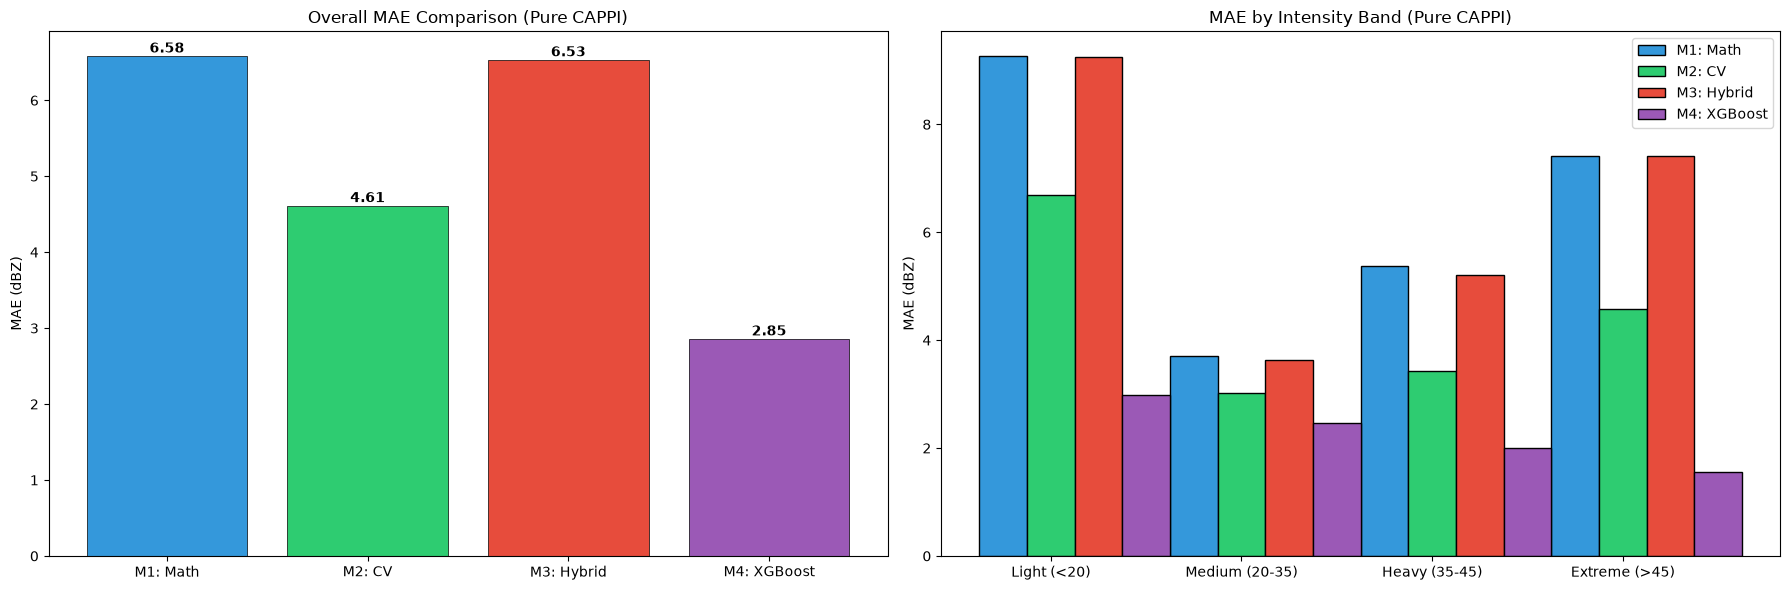

In [15]:
import pandas as pd

methods = {
    'M1: CAPPI Euclidean Mapping': summary_m1,
    'M2: CAPPI CV Distance Transform': summary_m2,
    'M3: CAPPI Hybrid Ensemble': summary_m3,
    'M4: XGBoost Machine Learning': summary_m4 # Correctly added summary_m4
}

band_names = ['Light Rain (< 20)', 'Medium Rain (20-35)', 'Heavy Rain (35-45)', 'Extreme (> 45)']
rows = []
for name, s in methods.items():
    row = {'Method': name, 'Overall MAE': f"{s['overall_mae']:.3f}"}
    for b in band_names:
        row[b] = f"{s['bands'][b]['mae']:.3f}"
    rows.append(row)

df = pd.DataFrame(rows)
print('=' * 110)
print('MAE COMPARISON TABLE OF METHODS (PURE CAPPI)')
print('=' * 110)
print(df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
method_names_short = ['M1: Math', 'M2: CV', 'M3: Hybrid', 'M4: XGBoost']
colors_bar = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6'] # Added a color for M4

overall_maes = [s['overall_mae'] for s in methods.values()]
bars = axes[0].bar(method_names_short, overall_maes, color=colors_bar, edgecolor='black', linewidth=0.5)
axes[0].set_ylabel('MAE (dBZ)')
axes[0].set_title('Overall MAE Comparison (Pure CAPPI)')
for bar, val in zip(bars, overall_maes):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, f'{val:.2f}', ha='center', fontweight='bold')

x = np.arange(len(band_names))
width = 0.25
for j, (name, s) in enumerate(methods.items()):
    maes = [s['bands'][b]['mae'] for b in band_names]
    # Ensure method_names_short and colors_bar are indexed correctly for all methods
    axes[1].bar(x + j * width, maes, width, label=method_names_short[j], color=colors_bar[j], edgecolor='black')

axes[1].set_xticks(x + width)
axes[1].set_xticklabels(['Light (<20)', 'Medium (20-35)', 'Heavy (35-45)', 'Extreme (>45)'])
axes[1].set_ylabel('MAE (dBZ)')
axes[1].set_title('MAE by Intensity Band (Pure CAPPI)')
axes[1].legend()
plt.tight_layout()
plt.savefig('cappi_final_comparison.png', dpi=300)
plt.show()